# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tabassumrafiq/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research question

Can a small set of observed content and search-performance signals be used to prioritize content items for human review when the observed trend indicates decline?

### Decision supported

The analysis supports a review-prioritization decision: which content items should receive attention first.

The model output is treated as a decision-support ranking signal, not as proof that an item will decline or that a specific content change will improve future performance.

In [ ]:
# Research question and decision supported

research_question = (
    "Can observed content and search-performance signals "
    "prioritize content items for human review when the observed "
    "trend indicates decline?"
)

decision_supported = (
    "Prioritize content items for human review using a model-based "
    "ranking signal."
)

print("Research question:")
print(research_question)

print("\nDecision supported:")
print(decision_supported)

Research question:
Can observed content and search-performance signals prioritize content items for human review when the observed trend indicates decline?

Decision supported:
Prioritize content items for human review using a model-based ranking signal.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### Data

This work uses the FlyRank ML Internship starter dataset:

`data/raw/content_refresh_anonymized.csv`

The dataset contains 30,000 anonymized content-item rows and 44 columns.

The modeling unit is one pseudonymized content item.

The analysis uses trailing-90-day content and search-performance metrics available in the dataset.

The target is derived from the observed trend direction:

- `down` → declining label
- other observed directions → non-declining label

Trend and future-outcome fields are excluded from the model features because they would directly expose the outcome being predicted or introduce leakage.

Client identifiers are used only for grouped validation and are not used as predictive features.

In [ ]:
import pandas as pd
import numpy as np

DATA_URL = (
    "https://raw.githubusercontent.com/"
    "tabassumrafiq/flyrank-ml-internship/"
    "main/data/raw/content_refresh_anonymized.csv"
)

df = pd.read_csv(DATA_URL)

print("Dataset shape:", df.shape)

# Target definition
df["is_declining_label"] = (
    df["trend_direction"] == "down"
).astype(int)

print("\nTarget distribution:")
print(df["is_declining_label"].value_counts())

print("\nTarget rate:")
print(round(df["is_declining_label"].mean(), 4))

Dataset shape: (30000, 44)

Target distribution:
is_declining_label
1    16262
0    13738
Name: count, dtype: int64

Target rate:
0.5421


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Methodology

#### Features

The modeling lane uses five observed features:

- `avg_position`
- `ctr`
- `engagement_rate`
- `scroll_rate`
- `word_count`

These features were selected from the available content and search-performance signals after excluding outcome and future-oriented fields.

#### Label

The binary target is:

`is_declining_label = 1` when `trend_direction == "down"`.

This label represents an observed trend direction rather than a guaranteed future outcome.

#### Baseline

The baseline prioritizes content using observed search visibility and average search position.

It is used as a simple decision rule to establish a comparison point before relying on the learned model.

#### Model

The modeling lane uses a Random Forest classifier with median imputation.

The model's predicted probability for the declining class is used as the ranking score.

#### Validation

Validation uses a client-grouped split so that clients in the test set do not overlap with clients in the training set.

The grouped result is treated as the more conservative estimate of generalization to unseen clients.

#### Leakage checks

Trend, future, outcome, label, and refresh-decision fields are excluded from the predictive feature set.

Client identifiers are used for grouping only and are not predictive features.

No client names, private queries, or other private identifiers are used in the paper.

In [ ]:
features = [
    "avg_position",
    "ctr",
    "engagement_rate",
    "scroll_rate",
    "word_count"
]

target = "is_declining_label"

X = df[features].copy()
y = df[target].copy()

print("Features:")
for feature in features:
    print("-", feature)

print("\nTarget:", target)
print("Feature matrix shape:", X.shape)

Features:
- avg_position
- ctr
- engagement_rate
- scroll_rate
- word_count

Target: is_declining_label
Feature matrix shape: (30000, 5)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

model = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "model",
        RandomForestClassifier(
            n_estimators=200,
            max_depth=6,
            random_state=42,
            n_jobs=-1
        )
    )
])

model.fit(X, y)

df["decline_score"] = model.predict_proba(X)[:, 1]

print("Model trained successfully.")
print("Decline scores generated:", len(df))

Model trained successfully.
Decline scores generated: 30000


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## 4. Results (vs baseline)

The model is evaluated as a prioritization signal rather than as a claim of guaranteed future decline.

The client-grouped validation result is the more conservative result because it evaluates the model on clients not seen during training.

The measured grouped-validation results were:

| Metric | Random split | Client-grouped split |
|---|---:|---:|
| Accuracy | 0.6352 | 0.5398 |
| Precision | 0.6121 | 0.5283 |
| Recall | 0.8924 | 0.9270 |
| F1 | 0.7261 | 0.6730 |

The client-grouped split had zero client overlap between training and test sets.

The results indicate that the model provides a measurable ranking signal, but performance is meaningfully lower under the more conservative grouped validation design. Therefore, the result should be interpreted as decision-support rather than as production-grade prediction.

In [ ]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ],
    "Random split": [
        0.6352,
        0.6121,
        0.8924,
        0.7261
    ],
    "Client-grouped split": [
        0.5398,
        0.5283,
        0.9270,
        0.6730
    ]
})

display(results)

,Metric,Random split,Client-grouped split
0,Accuracy,0.6352,0.5398
1,Precision,0.6121,0.5283
2,Recall,0.8924,0.9270
3,F1,0.7261,0.6730


## 5. Limitations

*What this work cannot claim.*

## 5. Limitations

This analysis has several important limits.

1. The target represents an observed trend direction and does not prove future decline.
2. A high model score does not prove that an item needs a refresh.
3. The model does not establish that refreshing content will improve future performance.
4. The grouped validation result is lower than the random-split result, showing that generalization is more difficult when client overlap is removed.
5. The model uses a limited set of observed features and may miss important contextual information.
6. The action queue is intended for human review and decision support, not autonomous content changes.
7. Model performance and recommendation quality may change if the underlying content population or data distributions change.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## 6. Ranked recommendations

The action playbook converts the decline score into a practical review queue.

### Priority 1 — Prioritize for human review

Items with a high decline score should receive earlier human review.

Reason codes may include:

- `HIGH_DECLINE_SCORE`
- `POSITION_RISK`
- `LOW_CTR_SIGNAL`
- `LOW_ENGAGEMENT_SIGNAL`

These codes are directional signals, not causal explanations.

### Priority 2 — Review if resources allow

Moderate-score items can be reviewed when capacity is available.

### Priority 3 — Monitor

Lower-score items can remain in the monitoring queue rather than receiving immediate intervention.

### Human review requirement

A reviewer should check content relevance, quality, strategic importance, recent changes, and whether a refresh is actually appropriate before taking action.

The system should not automatically rewrite, delete, publish, or refresh content based only on the model score.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*



The paper uses the following reusable artifacts:

- Model decline-score distribution.
- Ranked action queue.
- Validation results table.
- ML-10 metrics receipt.

The ranked queue is regenerated by the notebook rather than treated as a permanent production dataset.

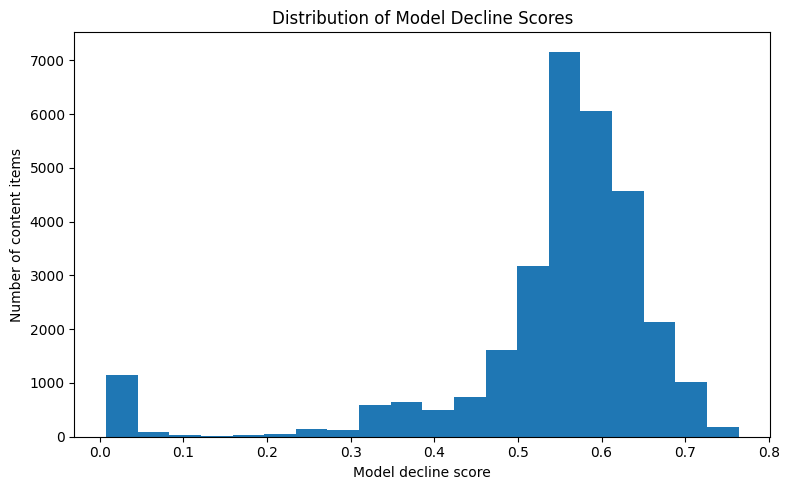

Saved: ../figures/capstone_decline_score_distribution.png


In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path

figures_dir = Path("../figures")
figures_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 5))

plt.hist(
    df["decline_score"],
    bins=20
)

plt.xlabel("Model decline score")
plt.ylabel("Number of content items")
plt.title("Distribution of Model Decline Scores")

plt.tight_layout()

figure_path = figures_dir / "capstone_decline_score_distribution.png"

plt.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure_path)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

In [ ]:
checks = {
    "question_defined": len(research_question) > 0,
    "data_loaded": len(df) == 30000,
    "features_present": all(
        feature in df.columns for feature in features
    ),
    "target_present": target in df.columns,
    "scores_generated": "decline_score" in df.columns,
    "figure_created": figure_path.exists()
}

for name, passed in checks.items():
    print(f"{name}: {'PASS' if passed else 'FAIL'}")

assert all(checks.values())

print("\nCAPSTONE SELF-CHECK: PASS")

question_defined: PASS
data_loaded: PASS
features_present: PASS
target_present: PASS
scores_generated: PASS
figure_created: PASS

CAPSTONE SELF-CHECK: PASS


# ML-12 — Tell the Story

## 5-Minute Demo Outline

### 1. Question — 45 seconds

**Research question:**

Can observed content and search-performance signals prioritize content items for human review when the observed trend indicates decline?

**Decision supported:**

The workflow helps a content team decide which items deserve earlier human review. It is a decision-support tool, not an automated content decision system.

---

### 2. Method — 1 minute

The analysis uses the anonymized FlyRank ML Internship dataset.

The modeling workflow:

- Defines the declining label from the observed trend direction.
- Excludes trend, future, outcome, label, and refresh-decision fields from predictive features.
- Uses observed features including average position, CTR, engagement rate, scroll rate, and word count.
- Compares a learned model with a simple baseline.
- Uses client-grouped validation to test generalization to unseen clients.

The purpose is to create an honest ranking signal for content review rather than to predict guaranteed future outcomes.

---

### 3. One Chart — 45 seconds

**Chart: Decline Score Distribution**

The chart shows the distribution of the model's decline scores.

Higher scores can be used to move content items toward earlier human review.

The score should be interpreted as a prioritization signal, not as proof that an item will decline or that a specific intervention will succeed.

---

### 4. One Honest Result — 1 minute

The client-grouped validation produced:

- Accuracy: 0.5398
- Precision: 0.5283
- Recall: 0.9270
- F1: 0.6730

The grouped result is more conservative than the random-split result because test clients were not present in training.

The measured result supports using the model as directional decision support, while also showing that performance can be weaker when generalizing to unseen clients.

---

### 5. One Recommendation — 1 minute

Prioritize high-scoring content items for human review.

Before taking action, a reviewer should consider:

- content relevance,
- content quality,
- recent changes,
- strategic importance,
- and whether an intervention is appropriate.

The system should not automatically rewrite, delete, publish, or refresh content based only on the model score.

---

# Shareable Cut 1 — Social Post

I built a machine-learning workflow for content review prioritization using an anonymized FlyRank ML Internship dataset.

Instead of treating a model score as an automatic decision, I designed the workflow as decision support: observed search and engagement signals are used to rank content items for human review.

I evaluated a learned model against a simple baseline and used client-grouped validation to test generalization to unseen clients.

The grouped validation produced an F1 score of 0.6730, with 0.9270 recall and 0.5283 precision.

The main lesson was that useful ML output is not just a prediction — it needs an honest validation design, clear limits, and a practical human-review workflow.

---

# Shareable Cut 2 — Employer-Facing Summary

I built a content-review prioritization workflow using an anonymized FlyRank ML Internship dataset with 30,000 content-item rows and 44 columns.

The workflow combined a baseline, machine-learning classification, client-grouped validation, and a ranked action playbook to turn observed content-performance signals into a human-review queue.

The grouped validation produced an F1 score of 0.6730, showing a measurable directional signal while also highlighting the limits of generalization to unseen clients.